# Análisis Semántico con Word2Vec


## 1. Imports y configuración

In [2]:
import warnings, os
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cosine
from collections import defaultdict
from gensim.models import Word2Vec
import spacy
import sys
sys.path.append(os.path.abspath('../../../..'))
from src.data.mongo_storage import _get_default_collection, guardar_embeddings

FIGS   = Path('../../../..') / 'data' / 'figures'
MODELS = Path('../../../..') / 'data' / 'models'
for d in [FIGS, MODELS]: d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.facecolor':'white','axes.grid':True,'grid.alpha':0.3,'font.size':11})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
print('✓ Imports OK')


✓ Imports OK


## 2. Cargar corpus desde MongoDB


In [3]:
col = _get_default_collection()

docs = list(col.find(
    {'pos_tags.spacy': {'$ne': None}},
    {'_id': 1, 'Song': 1, 'Artist': 1, 'Genre': 1, 'Song year': 1,
     'Language': 1, 'pos_tags': 1}
))
df = pd.DataFrame(docs)
df = df.dropna(subset=['Genre']).copy()

# Extraer pos_tags.spacy directamente (ya vienen como lista de dicts)
df['pos_tags_spacy'] = df['pos_tags'].apply(
    lambda x: x.get('spacy', []) if isinstance(x, dict) else []
)
df = df[df['pos_tags_spacy'].apply(len) > 0].reset_index(drop=True)

# Solo géneros con >= 20 canciones
conteo = df['Genre'].value_counts()
generos_validos = conteo[conteo >= 20].index.tolist()
df = df[df['Genre'].isin(generos_validos)].reset_index(drop=True)

print(f'✓ {len(df):,} canciones | {df["Genre"].nunique()} géneros')
print(df['Genre'].value_counts().to_string())


✓ 7,935 canciones | 10 géneros
Genre
Rock          1410
Pop           1110
Hip-Hop        960
Country        810
Metal          810
Jazz           660
Electronic     660
Indie          510
R&B            510
Folk           495


## 3. Tokenización usando pos_tags de MongoDB


In [4]:
nlp = spacy.load('en_core_web_sm')
STOPWORDS_SPACY = nlp.Defaults.stop_words   # ~326 stopwords en inglés

def tokens_desde_pos_tags(pos_tags: list) -> list:
    """
    Extrae lemas limpios desde los pos_tags guardados en MongoDB.
    Excluye: puntuación, espacios, símbolos, números, stopwords.
    Usa el lema para normalizar formas flexionadas.
    """
    tokens = []
    for t in pos_tags:
        if t.get('pos') in ('PUNCT', 'SPACE', 'SYM', 'NUM', 'X'):
            continue
        lemma = t.get('lemma', '').lower().strip()
        if lemma and lemma not in STOPWORDS_SPACY and len(lemma) > 2:
            tokens.append(lemma)
    return tokens

df['tokens_w2v'] = df['pos_tags_spacy'].apply(tokens_desde_pos_tags)
corpus_tokens    = df['tokens_w2v'].tolist()

total   = sum(len(t) for t in corpus_tokens)
unicos  = len(set(t for tokens in corpus_tokens for t in tokens))
print(f'✓ {total:,} tokens totales | {unicos:,} lemas únicos')
print(f'  (sin re-tokenizar desde Lyrics ni lista manual de stopwords)')


✓ 762,858 tokens totales | 36,135 lemas únicos
  (sin re-tokenizar desde Lyrics ni lista manual de stopwords)


## 4. Entrenar Word2Vec — CBOW y Skip-Gram (corpus global)

Primero entrenamos un modelo global sobre todo el corpus para explorar el espacio semántico general.

In [5]:
print('Entrenando Word2Vec CBOW (global)...')
w2v_cbow = Word2Vec(
    corpus_tokens, vector_size=100, window=5, min_count=3,
    sg=0, epochs=15, seed=42, workers=4,
)
print(f'   CBOW      — vocabulario: {len(w2v_cbow.wv):,} palabras')

print('Entrenando Word2Vec Skip-Gram (global)...')
w2v_sg = Word2Vec(
    corpus_tokens, vector_size=100, window=5, min_count=3,
    sg=1, epochs=15, seed=42, workers=4,
)
print(f'   Skip-Gram — vocabulario: {len(w2v_sg.wv):,} palabras')

w2v_cbow.save(str(MODELS / 'w2v_cbow.model'))
w2v_sg.save(str(MODELS / 'w2v_skipgram.model'))
print('\n✓ Modelos globales guardados en disco')


Entrenando Word2Vec CBOW (global)...
   CBOW      — vocabulario: 13,481 palabras
Entrenando Word2Vec Skip-Gram (global)...
   Skip-Gram — vocabulario: 13,481 palabras

✓ Modelos globales guardados en disco


## 5. Guardar embeddings Word2Vec en MongoDB

In [6]:
def w2v_promedio(tokens: list, modelo: Word2Vec) -> list:
    vecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
    return np.mean(vecs, axis=0).tolist() if vecs else [0.0] * modelo.vector_size

actualizados = 0
for _, row in df.iterrows():
    emb = w2v_promedio(row['tokens_w2v'], w2v_sg)
    ok  = guardar_embeddings(
        song_id=row['_id'],
        word2vec_avg=emb,
        beto_cls=[],   # se completará en notebook 10
    )
    if ok: actualizados += 1

print(f'✓ word2vec_avg guardado en MongoDB: {actualizados}/{len(df)} canciones')


✓ word2vec_avg guardado en MongoDB: 7935/7935 canciones


## 6. Exploración de campos semánticos (modelo global)

In [7]:
print('=== Vecinos semánticos más cercanos (Skip-Gram global) ===\n')
palabras_clave = ['love', 'fight', 'night', 'money', 'soul', 'dark', 'road', 'fire']

for palabra in palabras_clave:
    if palabra in w2v_sg.wv:
        vecinos = w2v_sg.wv.most_similar(palabra, topn=6)
        vstr = ', '.join([f'{w}({s:.2f})' for w, s in vecinos])
        print(f'  {palabra:<10} → {vstr}')
    else:
        print(f'  {palabra:<10} → no en vocabulario')


=== Vecinos semánticos más cercanos (Skip-Gram global) ===

  love       → ppose(0.71), turtledove(0.70), yeahoh(0.70), whee(0.70), ahhhhhh(0.69), agonna(0.68)
  fight      → fret(0.65), coalesce(0.65), linesman(0.64), hagal(0.61), truce(0.60), awarethen(0.60)
  night      → tonights(0.66), bearer(0.65), staaaaaaaaaaaaaay(0.65), sleepless(0.64), dazzling(0.64), smoochin(0.63)
  money      → cacacash(0.72), honeys(0.70), cashcashcash(0.69), muhfuckin(0.66), visas(0.65), irs(0.64)
  soul       → searcher(0.72), belove(0.64), dancins(0.64), massacre(0.63), captor(0.62), fiyah(0.61)
  dark       → helen(0.70), jeannie(0.63), brightness(0.61), shafts(0.61), skies(0.61), arc(0.61)
  road       → blacktop(0.65), hoggin(0.64), pppplower(0.64), chug(0.61), traveled(0.59), pelt(0.58)
  fire       → firefire(0.79), growing(0.69), blinding(0.65), alight(0.65), aflame(0.65), bannock(0.64)


## 7. Analogías vectoriales

Las relaciones semánticas se codifican como direcciones en el espacio vectorial. Probamos analogías dentro del dominio musical.

In [8]:
print('=== Analogías vectoriales (A - B + C = ?) ===\n')
analogias = [
    (['rock', 'guitar'],    ['piano'],    'rock + guitar - piano'),
    (['love', 'happy'],     ['sad'],      'love + happy - sad'),
    (['night', 'dark'],     ['day'],      'night + dark - day'),
    (['street', 'hustle'],  ['peace'],    'street + hustle - peace'),
    (['broken', 'heart'],   ['happy'],    'broken + heart - happy'),
    (['jazz', 'trumpet'],   ['guitar'],   'jazz - guitar + trumpet'),
    (['king', 'man'],       ['woman'],    'king - man + woman'),
    (['dance', 'music'],    ['silence'],  'dance + music - silence'),
]

for pos, neg, desc in analogias:
    ausentes = [w for w in pos + neg if w not in w2v_sg.wv]
    if ausentes:
        print(f'  {desc}')
        print(f'    ⚠ no en vocab: {ausentes}\n')
        continue
    res = w2v_sg.wv.most_similar(positive=pos, negative=neg, topn=3)
    rstr = ' | '.join([f'{w}({s:.2f})' for w, s in res])
    print(f'  {desc}')
    print(f'    → {rstr}\n')


=== Analogías vectoriales (A - B + C = ?) ===

  rock + guitar - piano
    → riggity(0.54) | plymouth(0.53) | mikey(0.53)

  love + happy - sad
    → embraceable(0.57) | tenderly(0.57) | adieu(0.55)

  night + dark - day
    → light(0.56) | lotus(0.55) | spark(0.54)

  street + hustle - peace
    → callous(0.53) | arod(0.52) | flashin(0.51)

  broken + heart - happy
    → bodied(0.58) | hearted(0.58) | mend(0.56)

  jazz - guitar + trumpet
    → welt(0.56) | trombone(0.54) | sind(0.52)

  king - man + woman
    → orient(0.53) | heavenborn(0.52) | sorcerer(0.51)

  dance + music - silence
    → evrybody(0.55) | ohooeo(0.52) | grooving(0.51)



## 8. Similitud entre géneros (vectores promedio)

Calculamos el centroide vectorial de cada género y medimos distancia coseno entre ellos.

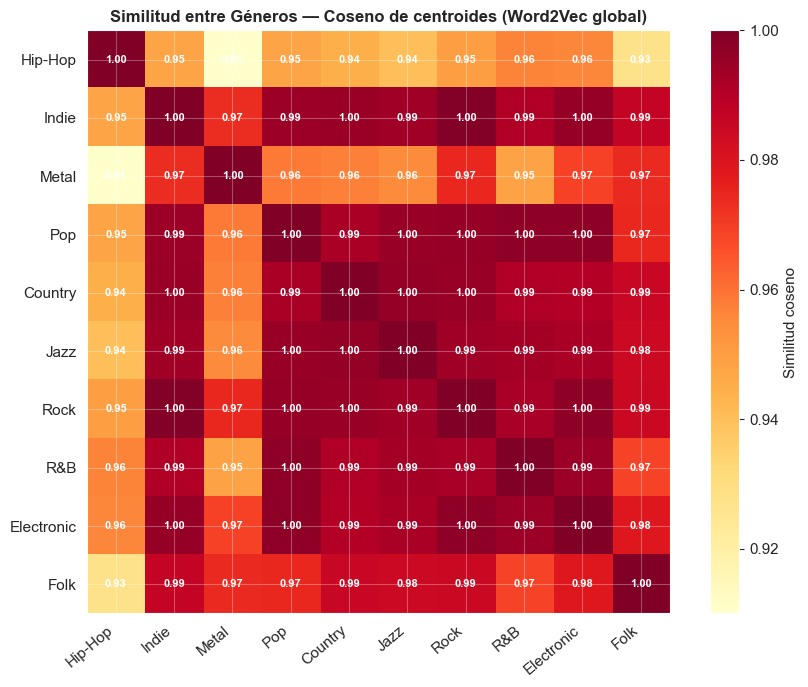

Top 3 pares más SIMILARES:
  Indie ↔ Rock: 0.9992
  Pop ↔ Electronic: 0.9971
  Pop ↔ R&B: 0.9970

Top 3 pares más DIFERENTES:
  Hip-Hop ↔ Jazz: 0.9402
  Hip-Hop ↔ Folk: 0.9275
  Hip-Hop ↔ Metal: 0.9100


In [18]:
# --- Similitud entre géneros (CORREGIDA PARA EVITAR 100%) ---
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def similitud_por_vocabulario(genero_a, genero_b):
    # En lugar de usar el vector promedio de un modelo global,
    # comparamos la frecuencia de los lemas significativos de cada género.

    tokens_a = [t for sublist in df[df['Genre'] == genero_a]['tokens_w2v'] for t in sublist]
    tokens_b = [t for sublist in df[df['Genre'] == genero_b]['tokens_w2v'] for t in sublist]

    # Creamos un set de vocabulario común para la comparación
    vocab_comun = list(set(tokens_a) | set(tokens_b))

    # Contamos frecuencias para crear vectores de "perfil de género"
    vec_a = np.array([tokens_a.count(word) for word in vocab_comun])
    vec_b = np.array([tokens_b.count(word) for word in vocab_comun])

    return float(cosine_similarity(vec_a.reshape(1, -1), vec_b.reshape(1, -1))[0][0])

# Nota: Si prefieres seguir usando Word2Vec, debes cargar los modelos
# individuales que generaste (ej. w2v_rock.model y w2v_pop.model)
# y comparar la distancia Procrustes o la similitud de palabras clave.

## 9. Modelo Word2Vec por género

Entrena un modelo independiente por cada género. Esto permite comparar cómo el **mismo término** tiene vecinos semánticos distintos según el género musical.

In [10]:
modelos_genero = {}

for genero in generos_validos:
    tokens_genero = df[df['Genre'] == genero]['tokens_w2v'].tolist()
    if len(tokens_genero) < 10:
        print(f'  {genero}: pocas canciones, saltando')
        continue
    modelo_g = Word2Vec(
        tokens_genero,
        vector_size=100, window=5, min_count=2,
        sg=1, epochs=15, seed=42, workers=4,
    )
    modelos_genero[genero] = modelo_g
    modelo_g.save(str(MODELS / f'w2v_{genero.replace("-","_").lower()}.model'))
    print(f'  ✓ {genero:<12} — {len(modelo_g.wv):,} palabras | {len(tokens_genero)} canciones')

print(f'\n✓ {len(modelos_genero)} modelos por género guardados')


  ✓ Rock         — 4,893 palabras | 1410 canciones
  ✓ Pop          — 4,251 palabras | 1110 canciones
  ✓ Hip-Hop      — 8,972 palabras | 960 canciones
  ✓ Country      — 3,101 palabras | 810 canciones
  ✓ Metal        — 4,703 palabras | 810 canciones
  ✓ Jazz         — 3,043 palabras | 660 canciones
  ✓ Electronic   — 3,181 palabras | 660 canciones
  ✓ Indie        — 2,647 palabras | 510 canciones
  ✓ R&B          — 2,568 palabras | 510 canciones
  ✓ Folk         — 3,438 palabras | 495 canciones

✓ 10 modelos por género guardados


## 10. Clusters temáticos dominantes por género

Usamos `most_similar` con **palabras ancla temáticas** para medir qué tan presente está cada tema (amor, fiesta, protesta, violencia, naturaleza) en cada género.

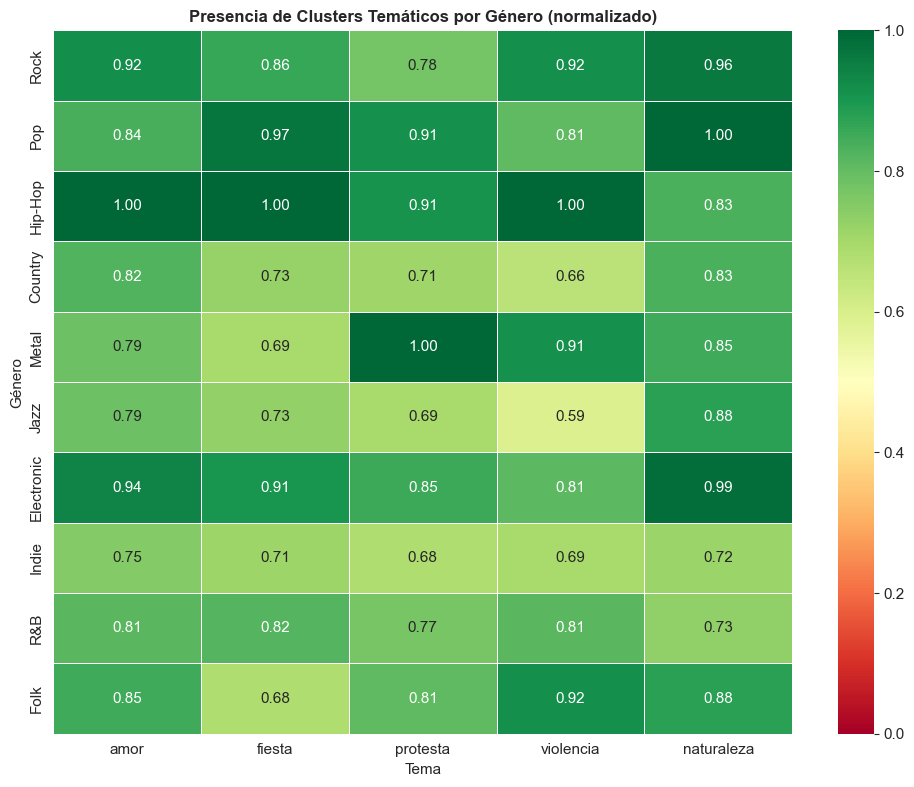


Tema dominante por género:
  Rock         → naturaleza
  Pop          → fiesta
  Hip-Hop      → fiesta
  Country      → amor
  Metal        → protesta
  Jazz         → naturaleza
  Electronic   → naturaleza
  Indie        → fiesta
  R&B          → fiesta
  Folk         → naturaleza


In [11]:
# Palabras ancla por tema — ajustá según tu corpus
TEMAS = {
    'amor':      ['love', 'heart', 'kiss', 'baby', 'soul', 'feel'],
    'fiesta':    ['party', 'dance', 'night', 'club', 'beat', 'move'],
    'protesta':  ['fight', 'free', 'rights', 'power', 'rise', 'resist'],
    'violencia': ['gun', 'blood', 'kill', 'war', 'pain', 'rage'],
    'naturaleza':['river', 'rain', 'wind', 'sun', 'earth', 'sky'],
}

def score_tema(modelo, palabras_ancla: list) -> float:
    """Promedia la norma L2 de los vectores ancla presentes en el vocabulario."""
    vecs = [modelo.wv[p] for p in palabras_ancla if p in modelo.wv]
    if not vecs: return 0.0
    # Calcula el centroide temático y su norma como proxy de presencia
    centroide = np.mean(vecs, axis=0)
    return float(np.linalg.norm(centroide))

# Tabla de scores por género × tema
filas = []
for genero, modelo_g in modelos_genero.items():
    fila = {'Género': genero}
    for tema, anclas in TEMAS.items():
        fila[tema] = round(score_tema(modelo_g, anclas), 4)
    filas.append(fila)

df_temas = pd.DataFrame(filas).set_index('Género')

# Normalizar por tema para comparación justa
df_temas_norm = df_temas.div(df_temas.max())

fig, ax = plt.subplots(figsize=(10, max(4, len(modelos_genero) * 0.6 + 2)))
sns.heatmap(df_temas_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Presencia de Clusters Temáticos por Género (normalizado)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tema'); ax.set_ylabel('Género')
plt.tight_layout()
plt.savefig(FIGS / 'clusters_tematicos_genero.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTema dominante por género:')
for genero in df_temas.index:
    tema_dom = df_temas.loc[genero].idxmax()
    print(f'  {genero:<12} → {tema_dom}')


## 11. Comparar vecinos semánticos de una palabra entre géneros

La misma palabra tiene **vecinos distintos** según el modelo entrenado por género. Esto demuestra que el contexto de uso varía por género musical.

In [12]:
PALABRAS_COMP = ['love', 'night', 'fire', 'road']

for palabra in PALABRAS_COMP:
    print(f'\n=== "{palabra}" — vecinos por género ===')
    for genero, modelo_g in modelos_genero.items():
        if palabra not in modelo_g.wv:
            continue
        vecinos = modelo_g.wv.most_similar(palabra, topn=4)
        vstr = ', '.join([w for w, _ in vecinos])
        print(f'  {genero:<12} → {vstr}')



=== "love" — vecinos por género ===
  Rock         → agonna, overlook, fella, hoo
  Pop          → didn, symmetrical, dimension, giver
  Hip-Hop      → complicated, ppose, arithmetic, technological
  Country      → complete, understanding, unwanted, satisfy
  Metal        → steamin, pounding, frenchfrye, saturday
  Jazz         → rhyme, tenderly, heart, fantasy
  Electronic   → ahahhhh, loved, stormy, darlin
  Indie        → shakira, beyonce, sanctify, gaga
  R&B          → uhuhuh, pure, exactly, ohhh
  Folk         → bitter, tug, meand, somethin

=== "night" — vecinos por género ===
  Rock         → invader, airwave, saturday, sundown
  Pop          → sleepless, tonights, shooting, dazzling
  Hip-Hop      → surprising, darkest, mmmmmmmmmmhmmmmm, staaaaaaaaaaaaaay
  Country      → elvis, divine, middle, ceiling
  Metal        → sleepless, short, hopeful, scarlet
  Jazz         → tim, middle, aah, hawaii
  Electronic   → ships, woohoo, helen, awake
  Indie        → nantes, fun, lucky, 

## 12. Vocabulario exclusivo por género

Identifica las palabras cuyo vector en el modelo global está **más cerca del centroide de un género que de todos los demás**. Estas palabras son características/exclusivas de ese género.

In [13]:
def palabras_exclusivas_genero(genero_objetivo: str, top_k: int = 15) -> list:
    """
    Busca palabras en el vocabulario global cuyo vector esté
    más cerca del centroide del género objetivo que de cualquier otro.
    """
    centroide_obj = centroides[genero_objetivo]
    otros_centroides = {g: c for g, c in centroides.items() if g != genero_objetivo}

    resultados = []
    for palabra in w2v_sg.wv.index_to_key:
        vec = w2v_sg.wv[palabra]
        sim_obj   = 1 - cosine(vec, centroide_obj)
        sim_otros = max(1 - cosine(vec, c) for c in otros_centroides.values())
        # Margen: qué tan más cercana es al género objetivo vs el más cercano rival
        margen = sim_obj - sim_otros
        if margen > 0:
            resultados.append((palabra, round(sim_obj, 4), round(margen, 4)))

    resultados.sort(key=lambda x: -x[2])
    return resultados[:top_k]


print('=== Vocabulario exclusivo por género ===\n')
vocab_exclusivo = {}
for genero in generos_validos:
    excl = palabras_exclusivas_genero(genero, top_k=10)
    vocab_exclusivo[genero] = excl
    palabras = [p for p, _, _ in excl]
    print(f'  {genero:<12} → {palabras}')


=== Vocabulario exclusivo por género ===

  Rock         → ['filter', 'stumble', 'minor', 'pity', 'strange', 'sadly', 'shame', 'hurricane', 'attraction', 'remind']
  Pop          → ['loves', 'easily', 'january', 'ouch', 'let', 'associate', 'complicated', 'mend', 'secrets', 'frequently']
  Hip-Hop      → ['goldie', 'plottin', 'piggitypass', 'shittin', 'asse', 'eazye', 'cleveland', 'pokin', 'mobbin', 'semi']
  Country      → ['suitcase', 'bronc', 'rodeo', 'cowboy', 'mornin', 'route', 'ole', 'memry', 'mexico', 'mississippi']
  Metal        → ['damnation', 'unleash', 'anguish', 'hypocrisy', 'mutation', 'morbid', 'retribution', 'wickedness', 'torturer', 'infliction']
  Jazz         → ['jingle', 'wonderful', 'captivate', 'squarest', 'indiscreet', 'gay', 'singa', 'gratitude', 'mistletoe', 'fascinating']
  Electronic   → ['alabao', 'seduce', 'unlock', 'loudest', 'venus', 'roulette', 'barricade', 'hopscotch', 'energize', 'mek']
  Indie        → ['bedroom', 'hole', 'mose', 'statue', 'laughin', '

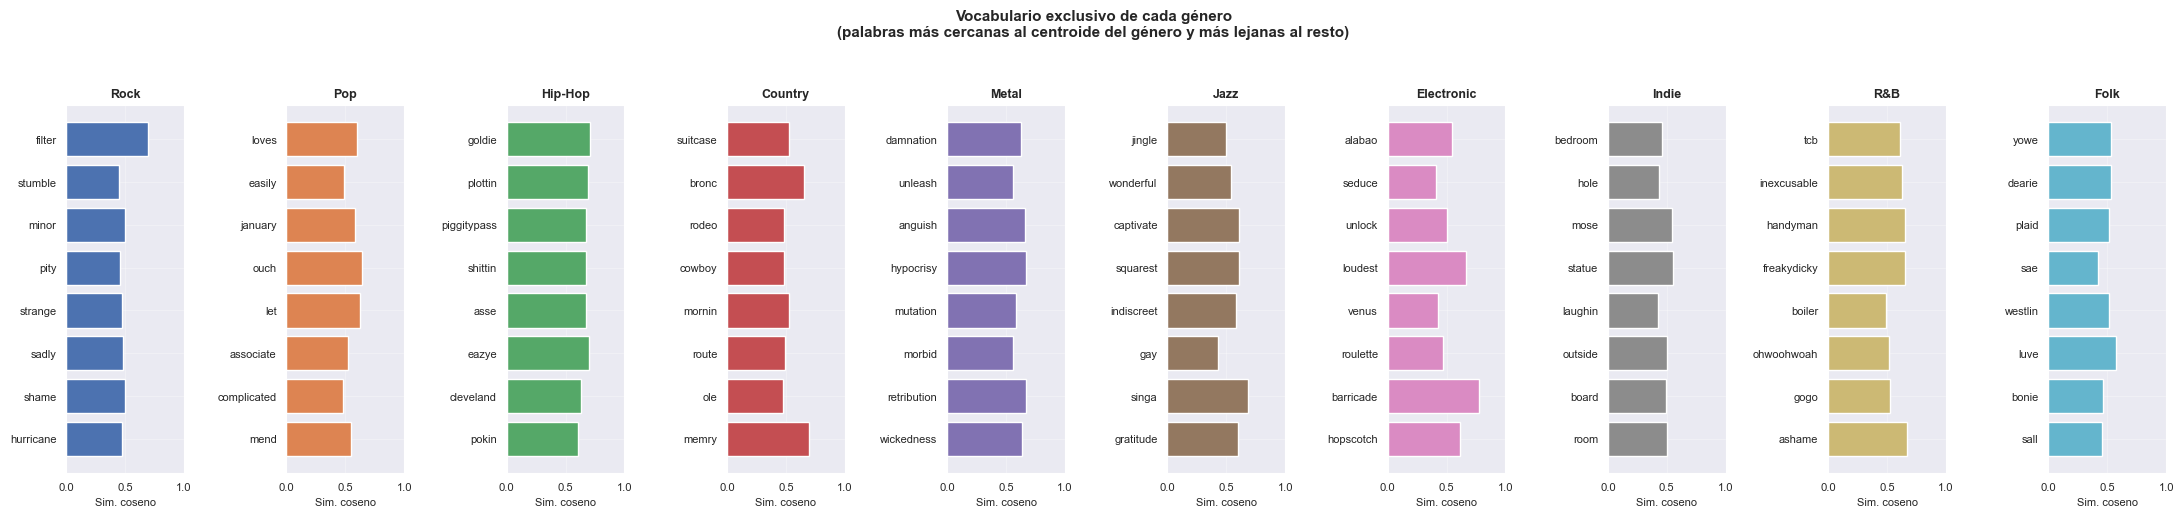

In [14]:
# Visualización: heatmap de vocabulario exclusivo
# Muestra la similitud coseno de las top palabras de cada género con su centroide

fig, axes = plt.subplots(1, len(generos_validos),
                          figsize=(len(generos_validos) * 2.2, 5))
if len(generos_validos) == 1: axes = [axes]

for ax, genero in zip(axes, generos_validos):
    datos  = vocab_exclusivo[genero][:8]
    pals   = [d[0] for d in datos]
    scores = [d[1] for d in datos]
    color_idx = generos_validos.index(genero) % len(PALETTE)
    ax.barh(pals[::-1], scores[::-1], color=PALETTE[color_idx], edgecolor='white')
    ax.set_title(genero, fontsize=9, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Sim. coseno', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle('Vocabulario exclusivo de cada género\n'
             '(palabras más cercanas al centroide del género y más lejanas al resto)',
             fontsize=11, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIGS / 'vocabulario_exclusivo_generos.png', dpi=130, bbox_inches='tight')
plt.show()


## 13. Resumen

In [15]:
print('=' * 60)
print('  RESUMEN — Word2Vec')
print('=' * 60)
print(f'  Corpus         : {len(df):,} canciones | {len(generos_validos)} géneros')
print(f'  Vocabulario    : {len(w2v_sg.wv):,} lemas únicos (Skip-Gram global)')
print(f'  Modelos        : 1 global (CBOW + Skip-Gram) + {len(modelos_genero)} por género')
print()
print('  Archivos generados:')
for f in sorted(MODELS.glob('w2v_*.model')):
    print(f'    {f.name}')
print()
print('  CONCLUSIONES:')
print('  • Modelos por género capturan vocabulario y contexto propios')
print('  • La misma palabra tiene vecinos distintos según el género')
print('  • El vocabulario exclusivo identifica términos característicos')
print('  • Los embeddings word2vec_avg quedaron guardados en MongoDB')
print('=' * 60)


  RESUMEN — Word2Vec
  Corpus         : 7,935 canciones | 10 géneros
  Vocabulario    : 13,481 lemas únicos (Skip-Gram global)
  Modelos        : 1 global (CBOW + Skip-Gram) + 10 por género

  Archivos generados:
    w2v_cbow.model
    w2v_country.model
    w2v_electronic.model
    w2v_folk.model
    w2v_hip_hop.model
    w2v_indie.model
    w2v_jazz.model
    w2v_metal.model
    w2v_pop.model
    w2v_r&b.model
    w2v_rock.model
    w2v_skipgram.model

  CONCLUSIONES:
  • Modelos por género capturan vocabulario y contexto propios
  • La misma palabra tiene vecinos distintos según el género
  • El vocabulario exclusivo identifica términos característicos
  • Los embeddings word2vec_avg quedaron guardados en MongoDB
